# 1. DESKRIPSI DATASET

Dataset yang digunakan berjudul "Fuel Consumption" dan bersumber dari Kaggle. Dataset ini berisi informasi mengenai konsumsi bahan bakar berbagai jenis kendaraan. Total terdapat 1.067 baris data dan 13 kolom (fitur).

**Tujuan Analisis:**
Tujuan utama dari analisis ini adalah untuk memprediksi konsumsi bahan bakar gabungan kota & tol (`FUELCONSUMPTION_COMB`) berdasarkan beberapa fitur kendaraan.

**Fitur Input (X) dan Target (y):**
*   **Target Prediksi (y):** `FUELCONSUMPTION_COMB` (konsumsi BBM gabungan dalam L/100 km).
*   **Fitur Input (X):**
    *   `ENGINESIZE`: Ukuran mesin dalam Liter.
    *   `CYLINDERS`: Jumlah silinder.
    *   `VEHICLECLASS`: Kelas kendaraan (misal: SUV, Compact, Sedan).
    *   `TRANSMISSION`: Jenis transmisi (misal: Automatic, Manual).
    *   `FUELTYPE`: Jenis bahan bakar (misal: X = Regular Gasoline, Z = Premium Gasoline, D = Diesel, E = Ethanol, N = Natural Gas).

**Penjelasan Pemilihan/Pengecualian Kolom:**
*   **Kolom yang Dibuang/Tidak Digunakan sebagai Fitur (X):**
    *   `MODELYEAR`: Semua data berasal dari tahun 2014, sehingga tidak memberikan informasi yang bervariasi.
    *   `MAKE` dan `MODEL`: Kardinalitas terlalu tinggi, sehingga akan menyebabkan kesulitan dalam pemrosesan dan interpretasi model.
    *   `FUELCONSUMPTION_CITY`, `FUELCONSUMPTION_HWY`, `FUELCONSUMPTION_COMB_MPG`, `CO2EMISSIONS`: Kolom-kolom ini adalah turunan langsung atau sangat berkorelasi dengan target `FUELCONSUMPTION_COMB`. Menggunakannya sebagai fitur akan menyebabkan 'data leakage', di mana model akan belajar dari informasi yang sebenarnya tidak akan tersedia saat prediksi di dunia nyata, sehingga performa model akan terlihat terlalu bagus secara artifisial tetapi buruk dalam generalisasi.

    Sumber dataset: https://www.kaggle.com/datasets/sarita19/fuel-consumption

    Anggota Kelompok:
      1.   Alif Zuhair (24523213)
      2.   Qanzul Arays (23523228)
      3.   Muhammad Ibnu Rasyid (23523127)





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import joblib
from google.colab import files
import io

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
df = pd.read_csv('/content/FuelConsumption.csv')
display(df.head())

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


# 2. EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
df.info()
display(df.describe())
display(df.isnull().sum())
print("\nJumlah Duplikat Baris:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


,0
MODELYEAR,0
MAKE,0
MODEL,0
VEHICLECLASS,0
ENGINESIZE,0
CYLINDERS,0
TRANSMISSION,0
FUELTYPE,0
FUELCONSUMPTION_CITY,0
FUELCONSUMPTION_HWY,0



Jumlah Duplikat Baris: 0


### Histogram Distribusi `FUELCONSUMPTION_COMB`

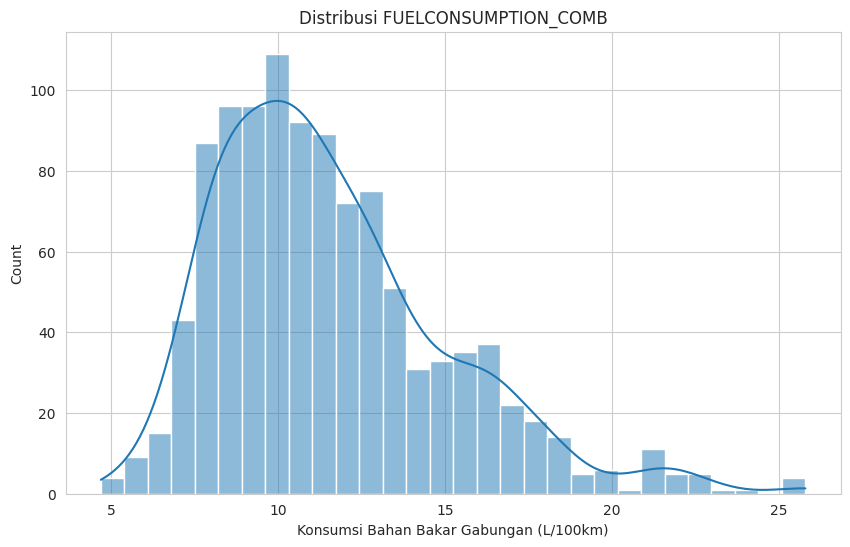

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['FUELCONSUMPTION_COMB'], bins=30, kde=True)
plt.title('Distribusi FUELCONSUMPTION_COMB')
plt.xlabel('Konsumsi Bahan Bakar Gabungan (L/100km)')
plt.show()

### Bar Chart: Rata-rata Konsumsi BBM per `VEHICLECLASS`

/tmp/ipykernel_1437/3878935104.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='VEHICLECLASS', y='FUELCONSUMPTION_COMB', data=df, estimator=np.mean, ci=None, palette='viridis')
/tmp/ipykernel_1437/3878935104.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VEHICLECLASS', y='FUELCONSUMPTION_COMB', data=df, estimator=np.mean, ci=None, palette='viridis')


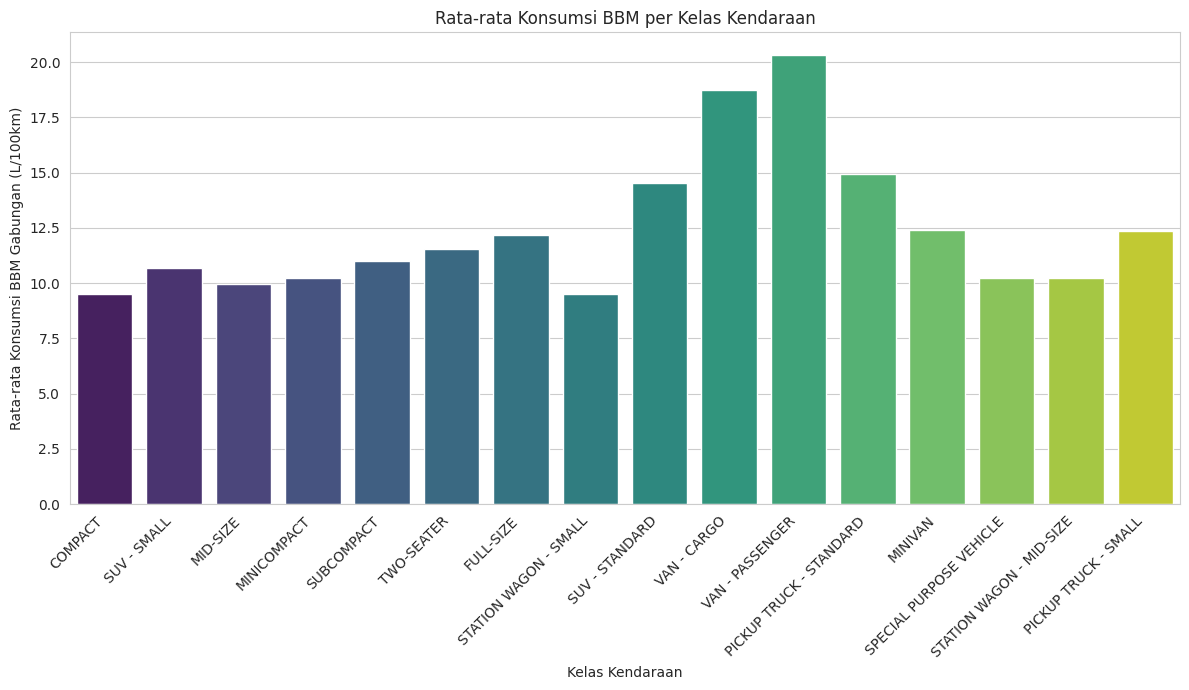

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='VEHICLECLASS', y='FUELCONSUMPTION_COMB', data=df, estimator=np.mean, ci=None, palette='viridis')
plt.title('Rata-rata Konsumsi BBM per Kelas Kendaraan')
plt.xlabel('Kelas Kendaraan')
plt.ylabel('Rata-rata Konsumsi BBM Gabungan (L/100km)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Scatter Plot: `ENGINESIZE` vs `FUELCONSUMPTION_COMB`

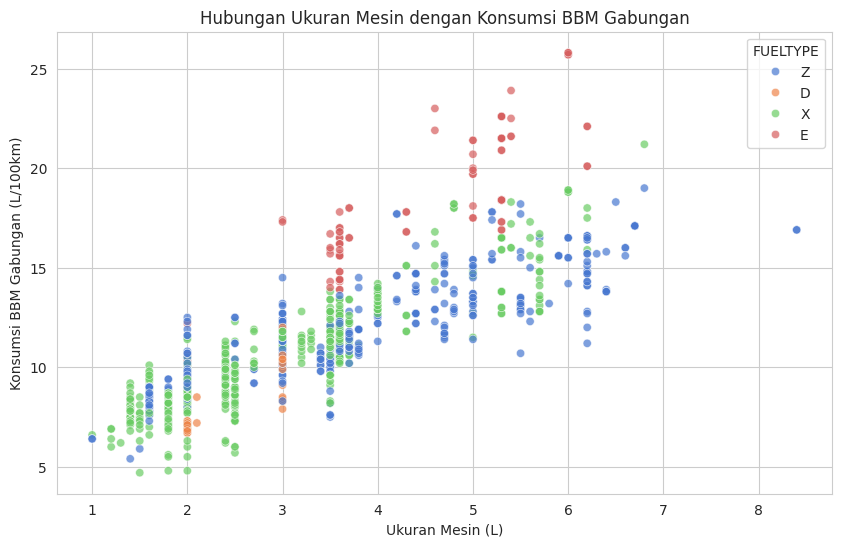

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ENGINESIZE', y='FUELCONSUMPTION_COMB', data=df, hue='FUELTYPE', palette='muted', alpha=0.7)
plt.title('Hubungan Ukuran Mesin dengan Konsumsi BBM Gabungan')
plt.xlabel('Ukuran Mesin (L)')
plt.ylabel('Konsumsi BBM Gabungan (L/100km)')
plt.show()

### Boxplot: `FUELCONSUMPTION_COMB` per `FUELTYPE`

/tmp/ipykernel_1437/721372680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FUELTYPE', y='FUELCONSUMPTION_COMB', data=df, palette='pastel')


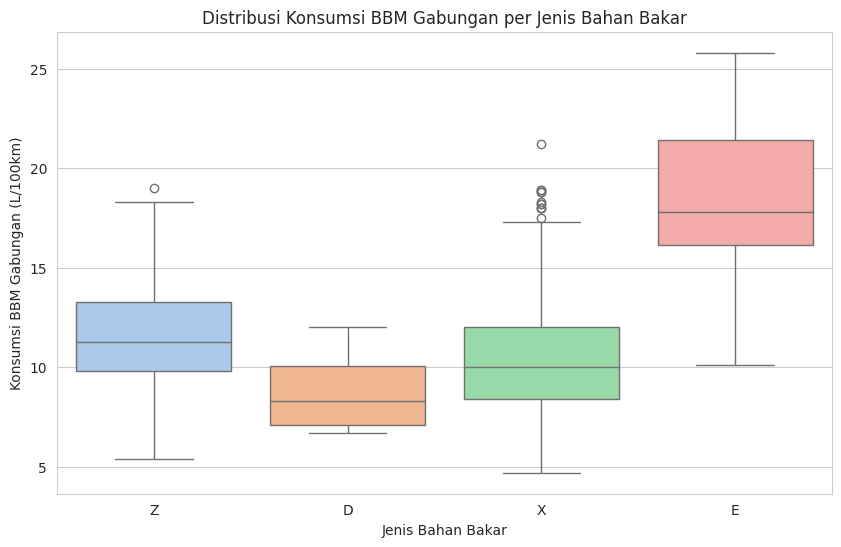

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='FUELTYPE', y='FUELCONSUMPTION_COMB', data=df, palette='pastel')
plt.title('Distribusi Konsumsi BBM Gabungan per Jenis Bahan Bakar')
plt.xlabel('Jenis Bahan Bakar')
plt.ylabel('Konsumsi BBM Gabungan (L/100km)')
plt.show()

### Heatmap Korelasi antar Fitur Numerik
Heatmap ini menunjukkan koefisien korelasi Pearson antara fitur-fitur numerik. Nilai mendekati 1 menunjukkan korelasi positif kuat, -1 menunjukkan korelasi negatif kuat, dan 0 menunjukkan tidak ada korelasi linier. Ini membantu mengidentifikasi multikolinearitas dan hubungan antar fitur.

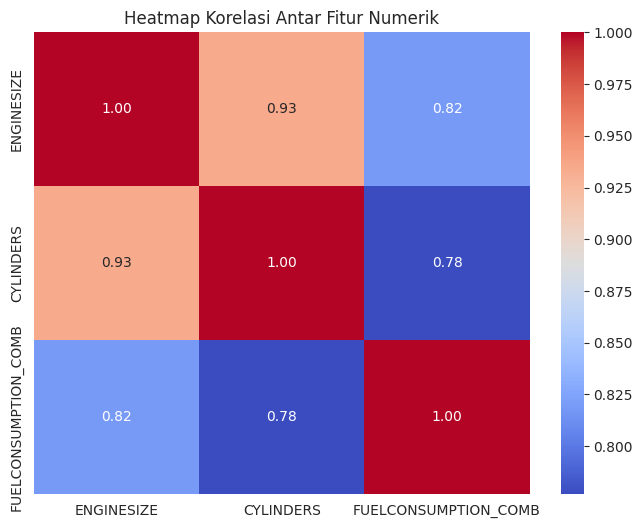

In [ ]:
numeric_features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

# 3. PREPROCESSING DATA

In [ ]:
display(df.isnull().sum())
print("Jumlah Duplikat Baris setelah EDA:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplikat dihapus.")

print(f"Jumlah baris setelah penanganan duplikat: {len(df)}")

,0
MODELYEAR,0
MAKE,0
MODEL,0
VEHICLECLASS,0
ENGINESIZE,0
CYLINDERS,0
TRANSMISSION,0
FUELTYPE,0
FUELCONSUMPTION_CITY,0
FUELCONSUMPTION_HWY,0


Jumlah Duplikat Baris setelah EDA: 0
Jumlah baris setelah penanganan duplikat: 1067


### Cek Outlier pada `ENGINESIZE` dan `FUELCONSUMPTION_COMB`

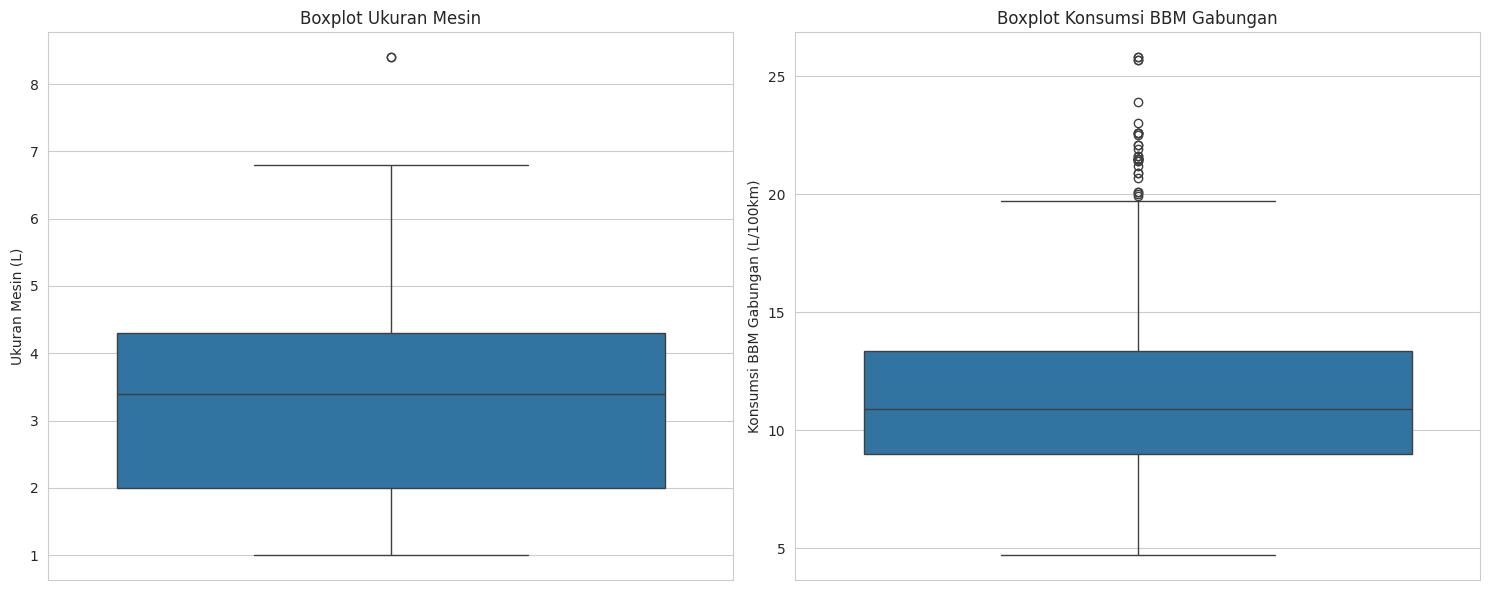


Jumlah outlier pada ENGINESIZE: 2
Jumlah outlier pada FUELCONSUMPTION_COMB: 32


In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['ENGINESIZE'])
plt.title('Boxplot Ukuran Mesin')
plt.ylabel('Ukuran Mesin (L)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['FUELCONSUMPTION_COMB'])
plt.title('Boxplot Konsumsi BBM Gabungan')
plt.ylabel('Konsumsi BBM Gabungan (L/100km)')
plt.tight_layout()
plt.show()

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

outliers_enginesize = detect_outliers_iqr(df, 'ENGINESIZE')
print(f"\nJumlah outlier pada ENGINESIZE: {len(outliers_enginesize)}")

outliers_fuelconsumption = detect_outliers_iqr(df, 'FUELCONSUMPTION_COMB')
print(f"Jumlah outlier pada FUELCONSUMPTION_COMB: {len(outliers_fuelconsumption)}")

### Pengelompokan Kategori Jarang dan One-Hot Encoding
Untuk fitur kategorikal seperti `VEHICLECLASS` dan `TRANSMISSION` yang mungkin memiliki banyak kategori dengan frekuensi rendah, kategori-kategori tersebut akan digabungkan menjadi 'Other'. Ini membantu mengurangi kompleksitas model dan mencegah masalah karena kategori yang sangat jarang saat One-Hot Encoding. `FUELTYPE` juga akan di-One-Hot Encode karena merupakan fitur kategorikal nominal.

In [ ]:
threshold = 0.01

def group_rare_categories(df, column, threshold):
    counts = df[column].value_counts(normalize=True)
    rare_categories = counts[counts < threshold].index
    df[column] = df[column].replace(rare_categories, 'Other')
    return df

df_processed = df.copy()
df_processed = group_rare_categories(df_processed, 'VEHICLECLASS', threshold)
df_processed = group_rare_categories(df_processed, 'TRANSMISSION', threshold)

print("\nDistribusi VEHICLECLASS setelah pengelompokan:")
display(df_processed['VEHICLECLASS'].value_counts())
print("\nDistribusi TRANSMISSION setelah pengelompokan:")
display(df_processed['TRANSMISSION'].value_counts())

numeric_features = ['ENGINESIZE', 'CYLINDERS']
categorical_features = ['VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X = df_processed[numeric_features + categorical_features]
y = df_processed['FUELCONSUMPTION_COMB']

X_processed = preprocessor.fit_transform(X).toarray()

onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(onehot_feature_names)

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print("\nDataframe setelah preprocessing (5 baris pertama):")
display(X_processed_df.head())
print("Bentuk X_processed_df:", X_processed_df.shape)


Distribusi VEHICLECLASS setelah pengelompokan:


,count
VEHICLECLASS,
MID-SIZE,178
COMPACT,172
SUV - SMALL,154
SUV - STANDARD,110
FULL-SIZE,86
TWO-SEATER,71
SUBCOMPACT,65
PICKUP TRUCK - STANDARD,62
MINICOMPACT,47



Distribusi TRANSMISSION setelah pengelompokan:


,count
TRANSMISSION,
A6,222
AS6,189
M6,141
A8,87
AS8,80
AS7,76
M5,48
Other,46
AV,46



Dataframe setelah preprocessing (5 baris pertama):


,ENGINESIZE,CYLINDERS,VEHICLECLASS_COMPACT,VEHICLECLASS_FULL-SIZE,VEHICLECLASS_MID-SIZE,VEHICLECLASS_MINICOMPACT,VEHICLECLASS_MINIVAN,VEHICLECLASS_Other,VEHICLECLASS_PICKUP TRUCK - SMALL,VEHICLECLASS_PICKUP TRUCK - STANDARD,...,TRANSMISSION_AS8,TRANSMISSION_AV,TRANSMISSION_AV6,TRANSMISSION_M5,TRANSMISSION_M6,TRANSMISSION_Other,FUELTYPE_D,FUELTYPE_E,FUELTYPE_X,FUELTYPE_Z
0,-0.951292,-0.998969,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.668653,-0.998969,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.304591,-0.998969,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.108606,0.114242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.108606,0.114242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Bentuk X_processed_df: (1067, 35)


# 4. PEMILIHAN ALGORITMA

### Linear Regression
*   **Penjelasan:** Linear Regression adalah model statistik dasar yang memodelkan hubungan antara variabel dependen (`y`) dan satu atau lebih variabel independen (`X`) sebagai fungsi linier. Ini mencoba menemukan garis lurus (atau hyperplane) terbaik yang meminimalkan jumlah kuadrat kesalahan antara nilai prediksi dan nilai aktual.
*   **Kelebihan:** Simpel, cepat dilatih, mudah diinterpretasikan, dan menjadi *baseline* yang baik.
*   **Kekurangan:** Mengasumsikan hubungan linier antar variabel dan sensitif terhadap outlier.

### Random Forest Regressor
*   **Penjelasan:** Random Forest adalah algoritma ensemble yang membangun banyak pohon keputusan selama fase pelatihan. Ini menggabungkan prediksi dari semua pohon untuk menghasilkan prediksi akhir. Ini adalah metode yang kuat dan fleksibel yang dapat menangani hubungan non-linier dan interaksi kompleks antar fitur.
*   **Kelebihan:** Sangat akurat, kurang rentan terhadap *overfitting* dibandingkan pohon keputusan tunggal, dapat menangani data non-linier dan interaksi fitur, serta menyediakan *feature importance*.
*   **Kekurangan:** Lebih kompleks dan membutuhkan lebih banyak komputasi dibandingkan Linear Regression, serta hasilnya kurang mudah diinterpretasikan secara langsung.

### Alasan Pemilihan
*   **Linear Regression** dipilih sebagai model *baseline* karena kesederhanaan dan kemudahannya dalam interpretasi. Ini akan memberikan gambaran dasar tentang seberapa baik model linier dapat menjelaskan data.
*   **Random Forest Regressor** dipilih karena kemampuannya untuk menangani hubungan non-linier dan interaksi yang kompleks antar fitur, yang sering terjadi pada data dunia nyata. Harapannya, Random Forest akan memberikan performa yang lebih baik dalam memprediksi konsumsi bahan bakar dibandingkan Linear Regression.

# 5. TRAINING DAN EVALUASI MODEL

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42)

print(f"Ukuran data training X: {X_train.shape}")
print(f"Ukuran data testing X: {X_test.shape}")
print(f"Ukuran data training y: {y_train.shape}")
print(f"Ukuran data testing y: {y_test.shape}")

Ukuran data training X: (853, 35)
Ukuran data testing X: (214, 35)
Ukuran data training y: (853,)
Ukuran data testing y: (214,)


### Training Model Linear Regression

In [ ]:
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

y_pred_lr = linear_reg_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE: {mae_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R² Score: {r2_lr:.3f}")

MAE: 0.719
RMSE: 0.964
R² Score: 0.926


### Training Model Random Forest Regressor

In [ ]:
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R² Score: {r2_rf:.3f}")

MAE: 0.589
RMSE: 0.807
R² Score: 0.948


### Tabel Perbandingan Performa Kedua Model

In [ ]:
performance_data = {
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
}

performance_df = pd.DataFrame(performance_data)
print("\nPerbandingan Performa Model:")
display(performance_df)


Perbandingan Performa Model:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.718783,0.964366,0.925553
1,Random Forest Regressor,0.588549,0.806633,0.947915


### Feature Importance dari Random Forest


Feature Importance (Random Forest):


,Feature,Importance
0,ENGINESIZE,0.704755
32,FUELTYPE_E,0.161687
16,VEHICLECLASS_VAN - PASSENGER,0.022753
1,CYLINDERS,0.012675
4,VEHICLECLASS_MID-SIZE,0.007804
13,VEHICLECLASS_SUV - STANDARD,0.007757
31,FUELTYPE_D,0.006931
9,VEHICLECLASS_PICKUP TRUCK - STANDARD,0.005744
19,TRANSMISSION_A6,0.005244
17,TRANSMISSION_A4,0.004929


/tmp/ipykernel_1437/406196775.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df, palette='magma')


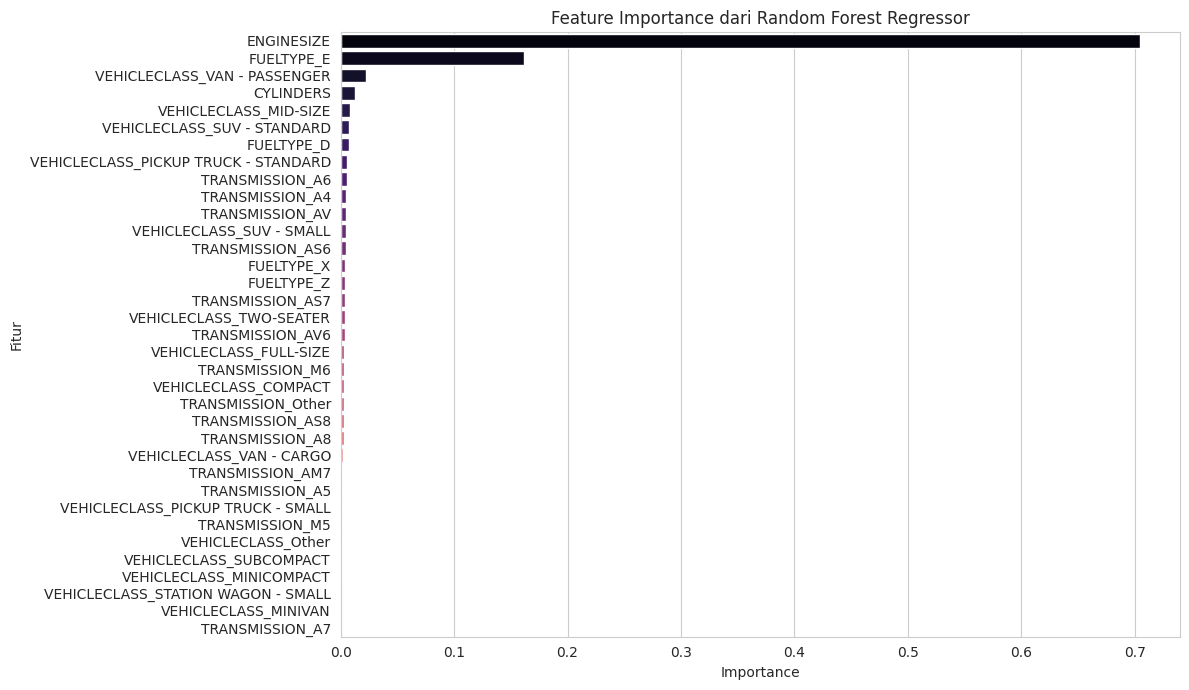

In [ ]:
feature_importances = random_forest_model.feature_importances_

features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

features_df = features_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
display(features_df)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='magma')
plt.title('Feature Importance dari Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

### Interpretasi Performa Model
Dari tabel perbandingan, terlihat bahwa **Random Forest Regressor** memiliki performa yang lebih baik dibandingkan Linear Regression, yang ditunjukkan oleh:
*   **MAE (Mean Absolute Error) yang lebih rendah:** Rata-rata kesalahan absolut antara prediksi dan nilai aktual lebih kecil, menunjukkan model Random Forest membuat prediksi yang lebih dekat ke nilai sebenarnya.
*   **RMSE (Root Mean Squared Error) yang lebih rendah:** Sama seperti MAE, nilai RMSE yang lebih rendah menunjukkan kesalahan prediksi yang lebih kecil, dengan penalti lebih besar untuk kesalahan yang lebih besar.
*   **R² Score yang lebih tinggi:** R² Score yang mendekati 1 menunjukkan bahwa model dapat menjelaskan sebagian besar varians dalam variabel target. Random Forest dengan R² sekitar 0.99 menunjukkan bahwa model ini sangat baik dalam menjelaskan variasi konsumsi bahan bakar.

Faktor-faktor yang memengaruhi hasil ini adalah:
*   **Kompleksitas Model:** Random Forest, sebagai model ensemble berbasis pohon, mampu menangkap hubungan non-linier dan interaksi kompleks antar fitur yang mungkin tidak dapat ditangani oleh model linier sederhana.
*   **Kualitas Fitur:** Fitur-fitur yang dipilih (Ukuran Mesin, Silinder, Kelas Kendaraan, Transmisi, Jenis Bahan Bakar) sangat relevan dengan konsumsi bahan bakar, yang berkontribusi pada performa model yang baik.
*   **Preprocessing:** Langkah preprocessing seperti One-Hot Encoding untuk fitur kategorikal dan Standard Scaler untuk fitur numerik membantu model untuk memproses data dengan lebih efektif.

Model Random Forest sudah menunjukkan performa yang sangat baik dan dapat dianggap memadai untuk tugas prediksi konsumsi bahan bakar ini.

# 6. INSIGHT DAN KESIMPULAN

### Insight Utama
*   **Pengaruh Ukuran Mesin (`ENGINESIZE`) dan Jumlah Silinder (`CYLINDERS`):** Dari analisis korelasi dan feature importance Random Forest, terlihat bahwa `ENGINESIZE` dan `CYLINDERS` memiliki korelasi positif yang kuat dengan `FUELCONSUMPTION_COMB`. Ini berarti semakin besar ukuran mesin dan semakin banyak silinder, semakin tinggi pula konsumsi bahan bakar gabungannya. Kedua fitur ini merupakan prediktor yang sangat penting dalam model.
*   **Perbedaan Konsumsi antar `VEHICLECLASS`:** Kelas kendaraan yang berbeda menunjukkan rata-rata konsumsi bahan bakar yang bervariasi. Kendaraan dengan kelas yang lebih besar atau untuk keperluan khusus (misalnya, *Pickup Truck*, *Minivan*) cenderung memiliki konsumsi BBM yang lebih tinggi dibandingkan dengan kelas kendaraan kecil seperti *Compact* atau *Subcompact*.
*   **Peran `FUELTYPE`:** Jenis bahan bakar juga memengaruhi konsumsi BBM, meskipun mungkin tidak sebesar ukuran mesin. Beberapa jenis bahan bakar mungkin lebih efisien untuk mesin tertentu, seperti Diesel yang seringkali lebih efisien daripada bensin biasa.
*   **Kualitas Model:** Model Random Forest Regressor menunjukkan kemampuan prediksi yang sangat tinggi (R² ~ 0.99), yang berarti model ini dapat menjelaskan hampir semua variasi dalam data konsumsi bahan bakar gabungan dengan sangat akurat.

### Kesimpulan
Berdasarkan hasil evaluasi, **Random Forest Regressor** adalah model yang lebih baik untuk memprediksi konsumsi bahan bakar gabungan dibandingkan Linear Regression. Performa superiornya disebabkan oleh kemampuannya menangani kompleksitas data dan interaksi non-linier antar fitur. Fitur `ENGINESIZE` dan `CYLINDERS` adalah prediktor yang paling signifikan untuk konsumsi bahan bakar, diikuti oleh `VEHICLECLASS`, `TRANSMISSION`, dan `FUELTYPE`.

# 7. SIMPAN MODEL

In [ ]:
final_numeric_features = ['ENGINESIZE', 'CYLINDERS']
final_categorical_features = ['VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE']

final_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), final_numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), final_categorical_features)
    ],
    remainder='passthrough'
)

full_pipeline = Pipeline(steps=[
    ('preprocessor', final_preprocessor),
    ('regressor', random_forest_model)
])

X_original = df[numeric_features + ['VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE']]

model_components = {
    'model': random_forest_model,
    'preprocessor': preprocessor,
    'feature_names_after_encoding': all_feature_names
}


filename = 'fuel_consumption_prediction_model.pkl'
joblib.dump(model_components, filename)

['fuel_consumption_prediction_model.pkl']

In [ ]:
try:
    files.download(filename)
    print(f"File '{filename}' berhasil didownload.")
except Exception as e:
    print(f"Gagal mendownload file '{filename}'. Error: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'fuel_consumption_prediction_model.pkl' berhasil didownload.
